In [ ]:
# Install required libraries
!pip install -q gymnasium stable-baselines3 shimmy

In [ ]:
# Import Required Libraries

# Data Manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# Reinforcement Learning
import gymnasium as gym
from gymnasium import spaces

from stable_baselines3 import DQN
from stable_baselines3.common.env_checker import check_env

# Utilities
import random
import warnings

# Ignore warnings
warnings.filterwarnings("ignore")

# Random seed for reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# Upload and Load Dataset

from google.colab import files

# Upload dataset
# uploaded = files.upload()

# Get uploaded file name
# file_name = list(uploaded.keys())[0]

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/BER (filtered and cleaned 20231005).csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [ ]:
# Initial Data Exploration

print("Dataset Shape:")
print(df.shape)

print("\nFirst Five Rows:")
display(df.head())

print("\nLast Five Rows:")
display(df.tail())

Dataset Shape:
(790389, 217)

First Five Rows:


,CountyName,DwellingTypeDescr,Year_of_Construction,TypeofRating,EnergyRating,BerRating,GroundFloorArea(sq m),UValueWall,UValueRoof,UValueFloor,UValueWindow,UvalueDoor,WallArea,RoofArea,FloorArea,WindowArea,DoorArea,NoStoreys,CO2Rating,MainSpaceHeatingFuel,MainWaterHeatingFuel,HSMainSystemEfficiency,MultiDwellingMPRN,TGDLEdition,MPCDERValue,HSEffAdjFactor,HSSupplHeatFraction,HSSupplSystemEff,WHMainSystemEff,WHEffAdjFactor,SupplSHFuel,SupplWHFuel,SHRenewableResources,WHRenewableResources,NoOfChimneys,NoOfOpenFlues,NoOfFansAndVents,NoOfFluelessGasFires,DraftLobby,VentilationMethod,FanPowerManuDeclaredValue,HeatExchangerEff,StructureType,SuspendedWoodenFloor,PercentageDraughtStripped,NoOfSidesSheltered,PermeabilityTest,PermeabilityTestResult,TempAdjustment,HeatSystemControlCat,HeatSystemResponseCat,NoCentralHeatingPumps,CHBoilerThermostatControlled,NoOilBoilerHeatingPumps,OBBoilerThermostatControlled,OBPumpInsideDwelling,NoGasBoilerHeatingPumps,WarmAirHeatingSystem,UndergroundHeating,GroundFloorUValue,DistributionLosses,StorageLosses,ManuLossFactorAvail,SolarHotWaterHeating,ElecImmersionInSummer,CombiBoiler,KeepHotFacility,WaterStorageVolume,DeclaredLossFactor,TempFactorUnadj,TempFactorMultiplier,InsulationType,InsulationThickness,PrimaryCircuitLoss,CombiBoilerAddLoss,ElecConsumpKeepHot,ApertureArea,ZeroLossCollectorEff,CollectorHeatLossCoEff,AnnualSolarRadiation,OvershadingFactor,CylinderStat,SolarStorageVolume,VolumeOfPreHeatStore,CombinedCylinder,ElectricityConsumption,SWHPumpSolarPowered,ChargingBasisHeatConsumed,gsdHSSupplHeatFraction,gsdHSSupplSystemEff,DistLossFactor,CHPUnitHeatFraction,CHPSystemType,CHPElecEff,CHPHeatEff,CHPFuelType,SupplHSFuelTypeID,gsdSHRenewableResources,gsdWHRenewableResources,SolarHeatFraction,DeliveredLightingEnergy,DeliveredEnergyPumpsFans,DeliveredEnergyMainWater,DeliveredEnergyMainSpace,PrimaryEnergyLighting,PrimaryEnergyPumpsFans,PrimaryEnergyMainWater,PrimaryEnergyMainSpace,CO2Lighting,CO2PumpsFans,CO2MainWater,CO2MainSpace,GroundFloorArea,GroundFloorHeight,FirstFloorArea,FirstFloorHeight,SecondFloorArea,SecondFloorHeight,ThirdFloorArea,ThirdFloorHeight,ThermalBridgingFactor,ThermalMassCategory,PredominantRoofTypeArea,PredominantRoofType,LowEnergyLightingPercent,TotalDeliveredEnergy,DeliveredEnergySecondarySpace,DeliveredEnergySupplementaryWater,LivingAreaPercent,CO2SecondarySpace,CO2SupplementaryWater,PrimaryEnergySecondarySpace,PrimaryEnergySupplementaryWater,HESSchemeUpgrade,RoomInRoofArea,PurposeOfRating,DateOfAssessment,FirstEnergyTypeId,FirstEnergyType_Description,FirstEnerProdComment,FirstEnerProdDelivered,FirstPartLTotalContribution,FirstEnerProdConvFactor,FirstEnerProdCO2EmissionFactor,FirstEnerConsumedComment,FirstEnerConsumedDelivered,FirstEnerConsumedConvFactor,FirstEnerConsumedCO2EmissionFactor,SecondEnergyTypeId,SecondEnergyType_Description,SecondEnerProdComment,SecondEnerProdDelivered,SecondPartLTotalContribution,SecondEnerProdConvFactor,SecondEnerProdCO2EmissionFactor,SecondEnerConsumedComment,SecondEnerConsumedDelivered,SecondEnerConsumedConvFactor,SecondEnerConsumedCO2EmissionFactor,ThirdEnergyTypeId,ThirdEnergyType_Description,ThirdEnerProdComment,ThirdEnerProdDelivered,ThirdPartLTotalContribution,ThirdEnerProdConvFactor,ThirdEnerProdCO2EmissionFactor,ThirdEnerConsumedComment,ThirdEnerConsumedDelivered,ThirdEnerConsumedConvFactor,ThirdEnerConsumedCO2EmissionFactor,FirstBoilerFuelType,FirstHeatGenPlantEff,FirstPercentageHeat,SecondBoilerFuelType,SecondHeatGenPlantEff,SecondPercentageHeat,ThirdBoilerFuelType,ThirdHeatGenPlantEff,ThirdPercentageHeat,SolarSpaceHeatingSystem,TotalPrimaryEnergyFact,TotalCO2Emissions,FirstWallType_Description,FirstWallArea,FirstWallUValue,FirstWallIsSemiExposed,FirstWallAgeBandId,FirstWallTypeId,SecondWallType_Description,SecondWallArea,SecondWallUValue,SecondWallIsSemiExposed,SecondWallAgeBandId,SecondWallTypeId,ThirdWallType_Description,ThirdWallArea,ThirdWallUValue,ThirdWallIsSemiExposed,ThirdWallAgeBandId,ThirdWallTypeId,SA_Code,prob_smarea_error


Last Five Rows:


,CountyName,DwellingTypeDescr,Year_of_Construction,TypeofRating,EnergyRating,BerRating,GroundFloorArea(sq m),UValueWall,UValueRoof,UValueFloor,UValueWindow,UvalueDoor,WallArea,RoofArea,FloorArea,WindowArea,DoorArea,NoStoreys,CO2Rating,MainSpaceHeatingFuel,MainWaterHeatingFuel,HSMainSystemEfficiency,MultiDwellingMPRN,TGDLEdition,MPCDERValue,HSEffAdjFactor,HSSupplHeatFraction,HSSupplSystemEff,WHMainSystemEff,WHEffAdjFactor,SupplSHFuel,SupplWHFuel,SHRenewableResources,WHRenewableResources,NoOfChimneys,NoOfOpenFlues,NoOfFansAndVents,NoOfFluelessGasFires,DraftLobby,VentilationMethod,FanPowerManuDeclaredValue,HeatExchangerEff,StructureType,SuspendedWoodenFloor,PercentageDraughtStripped,NoOfSidesSheltered,PermeabilityTest,PermeabilityTestResult,TempAdjustment,HeatSystemControlCat,HeatSystemResponseCat,NoCentralHeatingPumps,CHBoilerThermostatControlled,NoOilBoilerHeatingPumps,OBBoilerThermostatControlled,OBPumpInsideDwelling,NoGasBoilerHeatingPumps,WarmAirHeatingSystem,UndergroundHeating,GroundFloorUValue,DistributionLosses,StorageLosses,ManuLossFactorAvail,SolarHotWaterHeating,ElecImmersionInSummer,CombiBoiler,KeepHotFacility,WaterStorageVolume,DeclaredLossFactor,TempFactorUnadj,TempFactorMultiplier,InsulationType,InsulationThickness,PrimaryCircuitLoss,CombiBoilerAddLoss,ElecConsumpKeepHot,ApertureArea,ZeroLossCollectorEff,CollectorHeatLossCoEff,AnnualSolarRadiation,OvershadingFactor,CylinderStat,SolarStorageVolume,VolumeOfPreHeatStore,CombinedCylinder,ElectricityConsumption,SWHPumpSolarPowered,ChargingBasisHeatConsumed,gsdHSSupplHeatFraction,gsdHSSupplSystemEff,DistLossFactor,CHPUnitHeatFraction,CHPSystemType,CHPElecEff,CHPHeatEff,CHPFuelType,SupplHSFuelTypeID,gsdSHRenewableResources,gsdWHRenewableResources,SolarHeatFraction,DeliveredLightingEnergy,DeliveredEnergyPumpsFans,DeliveredEnergyMainWater,DeliveredEnergyMainSpace,PrimaryEnergyLighting,PrimaryEnergyPumpsFans,PrimaryEnergyMainWater,PrimaryEnergyMainSpace,CO2Lighting,CO2PumpsFans,CO2MainWater,CO2MainSpace,GroundFloorArea,GroundFloorHeight,FirstFloorArea,FirstFloorHeight,SecondFloorArea,SecondFloorHeight,ThirdFloorArea,ThirdFloorHeight,ThermalBridgingFactor,ThermalMassCategory,PredominantRoofTypeArea,PredominantRoofType,LowEnergyLightingPercent,TotalDeliveredEnergy,DeliveredEnergySecondarySpace,DeliveredEnergySupplementaryWater,LivingAreaPercent,CO2SecondarySpace,CO2SupplementaryWater,PrimaryEnergySecondarySpace,PrimaryEnergySupplementaryWater,HESSchemeUpgrade,RoomInRoofArea,PurposeOfRating,DateOfAssessment,FirstEnergyTypeId,FirstEnergyType_Description,FirstEnerProdComment,FirstEnerProdDelivered,FirstPartLTotalContribution,FirstEnerProdConvFactor,FirstEnerProdCO2EmissionFactor,FirstEnerConsumedComment,FirstEnerConsumedDelivered,FirstEnerConsumedConvFactor,FirstEnerConsumedCO2EmissionFactor,SecondEnergyTypeId,SecondEnergyType_Description,SecondEnerProdComment,SecondEnerProdDelivered,SecondPartLTotalContribution,SecondEnerProdConvFactor,SecondEnerProdCO2EmissionFactor,SecondEnerConsumedComment,SecondEnerConsumedDelivered,SecondEnerConsumedConvFactor,SecondEnerConsumedCO2EmissionFactor,ThirdEnergyTypeId,ThirdEnergyType_Description,ThirdEnerProdComment,ThirdEnerProdDelivered,ThirdPartLTotalContribution,ThirdEnerProdConvFactor,ThirdEnerProdCO2EmissionFactor,ThirdEnerConsumedComment,ThirdEnerConsumedDelivered,ThirdEnerConsumedConvFactor,ThirdEnerConsumedCO2EmissionFactor,FirstBoilerFuelType,FirstHeatGenPlantEff,FirstPercentageHeat,SecondBoilerFuelType,SecondHeatGenPlantEff,SecondPercentageHeat,ThirdBoilerFuelType,ThirdHeatGenPlantEff,ThirdPercentageHeat,SolarSpaceHeatingSystem,TotalPrimaryEnergyFact,TotalCO2Emissions,FirstWallType_Description,FirstWallArea,FirstWallUValue,FirstWallIsSemiExposed,FirstWallAgeBandId,FirstWallTypeId,SecondWallType_Description,SecondWallArea,SecondWallUValue,SecondWallIsSemiExposed,SecondWallAgeBandId,SecondWallTypeId,ThirdWallType_Description,ThirdWallArea,ThirdWallUValue,ThirdWallIsSemiExposed,ThirdWallAgeBandId,ThirdWallTypeId,SA_Code,prob_smarea_error

In [ ]:
# Dataset Information

print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 790389 entries, 0 to 790388
Columns: 217 entries, CountyName to Volume
dtypes: float64(152), int64(9), object(56)
memory usage: 1.3+ GB


In [ ]:
# Missing Values Analysis

missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df)) * 100
})

missing = missing[missing["Missing Values"] > 0]
missing = missing.sort_values(by="Percentage", ascending=False)

print("Missing Values Summary:")

if missing.empty:
    print("No missing values found.")
else:
    display(missing)

Missing Values Summary:


,Missing Values,Percentage
ThirdEnerConsumedComment,790359,99.996204
SecondEnerConsumedComment,790325,99.991903
ThirdEnerProdComment,790214,99.977859
FirstEnerConsumedComment,789354,99.869052
SecondEnerProdComment,788803,99.799339
...,...,...
HeatExchangerEff,304,0.038462
PermeabilityTestResult,304,0.038462
NoOfSidesSheltered,304,0.038462
PermeabilityTest,304,0.038462


In [ ]:
# Duplicate Records

duplicates = df.duplicated().sum()

print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 0


In [ ]:
# Display All Dataset Columns

pd.set_option('display.max_columns', None)

columns_df = pd.DataFrame({
    "Column Number": range(1, len(df.columns) + 1),
    "Column Name": df.columns
})

display(columns_df)

print(f"\nTotal Number of Columns: {len(df.columns)}")

,Column Number,Column Name
0,1,CountyName
1,2,DwellingTypeDescr
2,3,Year_of_Construction
3,4,TypeofRating
4,5,EnergyRating
...,...,...
212,213,UIDHex
213,214,County
214,215,ThermalEra
215,216,GlazingPercent



Total Number of Columns: 217


In [ ]:
# Separate Numerical and Categorical Features

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical Features : {len(numerical_cols)}")
print(f"Categorical Features : {len(categorical_cols)}")

print("\nNumerical Columns")
display(pd.DataFrame(numerical_cols, columns=["Numerical Features"]))

print("\nCategorical Columns")
display(pd.DataFrame(categorical_cols, columns=["Categorical Features"]))

Numerical Features : 161
Categorical Features : 56

Numerical Columns


,Numerical Features
0,Year_of_Construction
1,BerRating
2,GroundFloorArea(sq m)
3,UValueWall
4,UValueRoof
...,...
156,EPC
157,PUValueWall
158,PUValueRoof
159,GlazingPercent



Categorical Columns


,Categorical Features
0,CountyName
1,DwellingTypeDescr
2,TypeofRating
3,EnergyRating
4,MainSpaceHeatingFuel
5,MainWaterHeatingFuel
6,MultiDwellingMPRN
7,DraftLobby
8,VentilationMethod
9,StructureType


In [ ]:
# Missing Value Percentage

missing_summary = pd.DataFrame({
    "Column": df.columns,
    "Missing Values": df.isnull().sum(),
    "Missing (%)": round(df.isnull().mean() * 100, 2)
})

missing_summary = missing_summary.sort_values(
    by="Missing (%)",
    ascending=False
)

display(missing_summary)

,Column,Missing Values,Missing (%)
ThirdEnerConsumedComment,ThirdEnerConsumedComment,790359,100.00
SecondEnerConsumedComment,SecondEnerConsumedComment,790325,99.99
ThirdEnerProdComment,ThirdEnerProdComment,790214,99.98
FirstEnerConsumedComment,FirstEnerConsumedComment,789354,99.87
SecondEnerProdComment,SecondEnerProdComment,788803,99.80
...,...,...,...
UIDHex,UIDHex,0,0.00
County,County,0,0.00
ThermalEra,ThermalEra,0,0.00
GlazingPercent,GlazingPercent,0,0.00


In [ ]:
# Select Relevant Features

selected_features = [
    "DwellingTypeDescr",
    "Year_of_Construction",
    "GroundFloorArea(sq m)",
    "EnergyRating",
    "BerRating",
    "UValueWall",
    "UValueRoof",
    "UValueFloor",
    "MainSpaceHeatingFuel",
    "MainWaterHeatingFuel",
    "ThermalEra",
    "GlazingPercent",
    "Volume"
]

# Keep only selected features
retrofit_df = df[selected_features].copy()

print("Selected Dataset Shape:")
print(retrofit_df.shape)

display(retrofit_df.head())

Selected Dataset Shape:
(790389, 13)


,DwellingTypeDescr,Year_of_Construction,GroundFloorArea(sq m),EnergyRating,BerRating,UValueWall,UValueRoof,UValueFloor,MainSpaceHeatingFuel,MainWaterHeatingFuel,ThermalEra,GlazingPercent,Volume
0,Semi-detached house,1960,110.10,D2,267.11,0.52,0.51,0.63,Heating Oil,Heating Oil,Pre,0.260241,583.5300
1,Semi-detached house,1967,103.60,G,589.52,1.63,0.71,0.58,Heating Oil,Heating Oil,Pre,0.177655,549.0800
2,Semi-detached house,1975,94.06,E2,373.70,1.54,0.26,0.84,Heating Oil,Heating Oil,Pre,0.170429,480.6466
3,Semi-detached house,1929,86.37,F,431.85,2.02,0.49,0.80,Mains Gas,Mains Gas,Pre,0.199715,494.9001
4,Detached house,1949,72.22,D1,227.06,0.60,0.13,0.84,Heating Oil,Heating Oil,Pre,0.171896,192.8274


In [ ]:
# Missing Values in Selected Features

missing = pd.DataFrame({
    "Missing Values": retrofit_df.isnull().sum(),
    "Percentage": round(retrofit_df.isnull().mean()*100,2)
})

display(missing)

,Missing Values,Percentage
DwellingTypeDescr,0,0.00
Year_of_Construction,0,0.00
GroundFloorArea(sq m),0,0.00
EnergyRating,0,0.00
BerRating,0,0.00
UValueWall,0,0.00
UValueRoof,0,0.00
UValueFloor,0,0.00
MainSpaceHeatingFuel,12867,1.63
MainWaterHeatingFuel,12867,1.63


In [ ]:
# Handle Missing Values

categorical_columns = [
    "MainSpaceHeatingFuel",
    "MainWaterHeatingFuel"
]

for col in categorical_columns:
    retrofit_df[col].fillna(retrofit_df[col].mode()[0], inplace=True)

print("Missing Values After Imputation:")
print(retrofit_df.isnull().sum())

Missing Values After Imputation:
DwellingTypeDescr        0
Year_of_Construction     0
GroundFloorArea(sq m)    0
EnergyRating             0
BerRating                0
UValueWall               0
UValueRoof               0
UValueFloor              0
MainSpaceHeatingFuel     0
MainWaterHeatingFuel     0
ThermalEra               0
GlazingPercent           0
Volume                   0
dtype: int64


In [ ]:
# Sample Dataset for DRL Training

SAMPLE_SIZE = 10000

retrofit_df = retrofit_df.sample(
    n=SAMPLE_SIZE,
    random_state=42
).reset_index(drop=True)

print("Sampled Dataset Shape:")
print(retrofit_df.shape)

display(retrofit_df.head())

Sampled Dataset Shape:
(10000, 13)


,DwellingTypeDescr,Year_of_Construction,GroundFloorArea(sq m),EnergyRating,BerRating,UValueWall,UValueRoof,UValueFloor,MainSpaceHeatingFuel,MainWaterHeatingFuel,ThermalEra,GlazingPercent,Volume
0,Detached house,2002,143.03,C1,170.59,0.55,0.23,0.44,Heating Oil,Heating Oil,Post,0.197692,752.3378
1,Top-floor apartment,1981,55.87,E1,330.22,0.64,0.68,0.00,Bulk LPG (propane or butane),Bulk LPG (propane or butane),Post,0.216167,131.8532
2,Detached house,1960,70.80,C3,223.32,0.32,0.13,0.73,Mains Gas,Mains Gas,Pre,0.197599,189.0360
3,Detached house,1991,155.55,D1,237.30,0.57,0.23,0.59,Mains Gas,Mains Gas,Post,0.192377,824.4150
4,Semi-detached house,2004,108.16,C1,164.43,0.55,0.27,0.44,Mains Gas,Mains Gas,Post,0.158451,559.1872


In [ ]:
# Dataset Summary

print(retrofit_df.info())

print("\nNumerical Summary")
display(retrofit_df.describe())

print("\nCategorical Summary")
display(retrofit_df.describe(include='object'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   DwellingTypeDescr      10000 non-null  object 
 1   Year_of_Construction   10000 non-null  int64  
 2   GroundFloorArea(sq m)  10000 non-null  float64
 3   EnergyRating           10000 non-null  object 
 4   BerRating              10000 non-null  float64
 5   UValueWall             10000 non-null  float64
 6   UValueRoof             10000 non-null  float64
 7   UValueFloor            10000 non-null  float64
 8   MainSpaceHeatingFuel   10000 non-null  object 
 9   MainWaterHeatingFuel   10000 non-null  object 
 10  ThermalEra             10000 non-null  object 
 11  GlazingPercent         10000 non-null  float64
 12  Volume                 10000 non-null  float64
dtypes: float64(7), int64(1), object(5)
memory usage: 1015.8+ KB
None

Numerical Summary


,Year_of_Construction,GroundFloorArea(sq m),BerRating,UValueWall,UValueRoof,UValueFloor,GlazingPercent,Volume
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1985.207400,111.183273,229.643438,0.669190,0.289629,0.433814,0.245815,499.269207
std,29.709784,49.696802,129.955982,0.576696,0.283947,0.236096,0.801121,316.294914
min,1760.000000,15.970000,-36.880000,0.140000,0.000000,0.000000,0.029798,0.000000
25%,1975.000000,79.507500,160.007500,0.300000,0.130000,0.340000,0.154582,272.493150
50%,1997.000000,98.945000,204.705000,0.400000,0.210000,0.410000,0.196482,454.490000
75%,2004.000000,128.445000,270.275000,0.700000,0.360000,0.600000,0.262944,615.207075
max,2023.000000,392.090000,4883.850000,3.280000,1.990000,1.130000,78.029412,3700.579200



Categorical Summary


,DwellingTypeDescr,EnergyRating,MainSpaceHeatingFuel,MainWaterHeatingFuel,ThermalEra
count,10000,10000,10000,10000,10000
unique,10,15,13,12,2
top,Detached house,C2,Mains Gas,Mains Gas,Post
freq,3149,1413,4220,4205,7227


In [ ]:
# Encode Categorical Features

from sklearn.preprocessing import LabelEncoder

# Create a copy
processed_df = retrofit_df.copy()

# Store encoders for later interpretation
label_encoders = {}

categorical_columns = [
    "DwellingTypeDescr",
    "EnergyRating",
    "MainSpaceHeatingFuel",
    "MainWaterHeatingFuel",
    "ThermalEra"
]

for col in categorical_columns:
    encoder = LabelEncoder()
    processed_df[col] = encoder.fit_transform(processed_df[col].astype(str))
    label_encoders[col] = encoder

print("Categorical variables encoded successfully.")

display(processed_df.head())

Categorical variables encoded successfully.


,DwellingTypeDescr,Year_of_Construction,GroundFloorArea(sq m),EnergyRating,BerRating,UValueWall,UValueRoof,UValueFloor,MainSpaceHeatingFuel,MainWaterHeatingFuel,ThermalEra,GlazingPercent,Volume
0,1,2002,143.03,6,170.59,0.55,0.23,0.44,3,3,0,0.197692,752.3378
1,9,1981,55.87,11,330.22,0.64,0.68,0.00,1,1,0,0.216167,131.8532
2,1,1960,70.80,8,223.32,0.32,0.13,0.73,5,5,1,0.197599,189.0360
3,1,1991,155.55,9,237.30,0.57,0.23,0.59,5,5,0,0.192377,824.4150
4,8,2004,108.16,6,164.43,0.55,0.27,0.44,5,5,0,0.158451,559.1872


In [ ]:
print("EnergyRating order:", list(label_encoders["EnergyRating"].classes_))
print("MainSpaceHeatingFuel order:", list(label_encoders["MainSpaceHeatingFuel"].classes_))

EnergyRating order: ['A1', 'A2', 'A3', 'B1', 'B2', 'B3', 'C1', 'C2', 'C3', 'D1', 'D2', 'E1', 'E2', 'F ', 'G ']
MainSpaceHeatingFuel order: ['Bottled LPG                   ', 'Bulk LPG (propane or butane)  ', 'Electricity                   ', 'Heating Oil                   ', 'House Coal                    ', 'Mains Gas                     ', 'Manufactured Smokeless Fuel   ', 'Peat Briquettes               ', 'Sod Peat                      ', 'Solid Multi-Fuel              ', 'Wood Logs                     ', 'Wood Pellets (bulk supply for ', 'Wood Pellets (in bags for seco']


In [ ]:
# Scale Numerical Features

from sklearn.preprocessing import StandardScaler

numerical_columns = [
    "Year_of_Construction",
    "GroundFloorArea(sq m)",
    "BerRating",
    "UValueWall",
    "UValueRoof",
    "UValueFloor",
    "GlazingPercent",
    "Volume"
]

scaler = StandardScaler()

processed_df[numerical_columns] = scaler.fit_transform(
    processed_df[numerical_columns]
)

print("Numerical variables standardized successfully.")

display(processed_df.head())

Numerical variables standardized successfully.


,DwellingTypeDescr,Year_of_Construction,GroundFloorArea(sq m),EnergyRating,BerRating,UValueWall,UValueRoof,UValueFloor,MainSpaceHeatingFuel,MainWaterHeatingFuel,ThermalEra,GlazingPercent,Volume
0,1,0.565249,0.640852,6,-0.454434,-0.206688,-0.210011,0.026203,3,3,0,-0.060072,0.800143
1,9,-0.141624,-1.113070,11,0.773967,-0.050618,1.374870,-1.837539,1,1,0,-0.037010,-1.161683
2,1,-0.848497,-0.812634,8,-0.048661,-0.605531,-0.562206,1.254578,5,5,1,-0.060188,-0.980884
3,1,0.194983,0.892793,9,0.058920,-0.172006,-0.210011,0.661569,5,5,0,-0.066708,1.028034
4,8,0.632571,-0.060837,6,-0.501837,-0.206688,-0.069132,0.026203,5,5,0,-0.109058,0.189447


In [ ]:
# Create State Matrix

state_columns = [
    "DwellingTypeDescr",
    "Year_of_Construction",
    "GroundFloorArea(sq m)",
    "EnergyRating",
    "BerRating",
    "UValueWall",
    "UValueRoof",
    "UValueFloor",
    "MainSpaceHeatingFuel",
    "MainWaterHeatingFuel",
    "ThermalEra",
    "GlazingPercent",
    "Volume"
]

state_matrix = processed_df[state_columns].values

print("State Matrix Shape:")
print(state_matrix.shape)

print("\nFirst State Vector:")
print(state_matrix[0])

State Matrix Shape:
(10000, 13)

First State Vector:
[ 1.          0.56524948  0.64085249  6.         -0.4544338  -0.20668769
 -0.21001078  0.02620251  3.          3.          0.         -0.06007227
  0.80014327]


In [ ]:
# Save Processed Dataset

processed_df.to_csv(
    "processed_retrofit_dataset.csv",
    index=False
)

print("Processed dataset saved successfully.")

Processed dataset saved successfully.


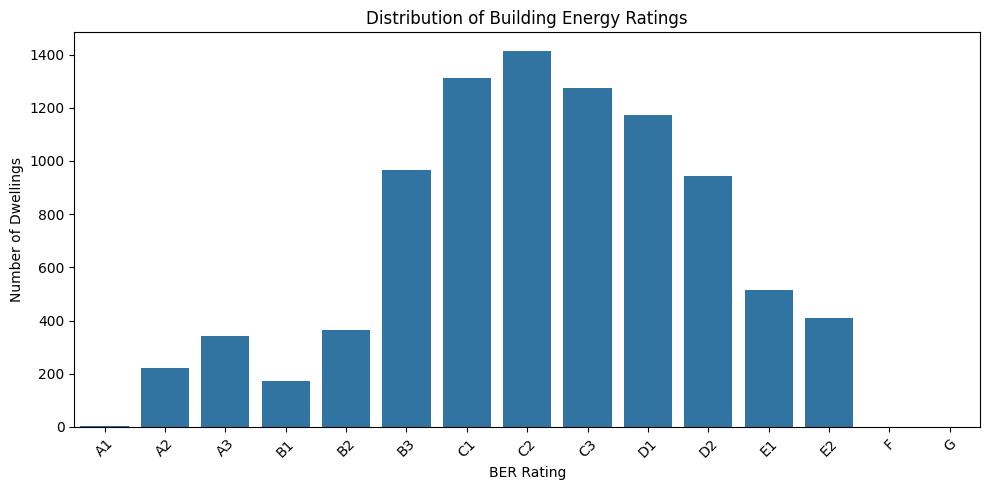

In [ ]:
# Distribution of BER Ratings

plt.figure(figsize=(10,5))

order = [
    "A1","A2","A3",
    "B1","B2","B3",
    "C1","C2","C3",
    "D1","D2",
    "E1","E2",
    "F","G"
]

sns.countplot(
    data=retrofit_df,
    x="EnergyRating",
    order=order
)

plt.title("Distribution of Building Energy Ratings")
plt.xlabel("BER Rating")
plt.ylabel("Number of Dwellings")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

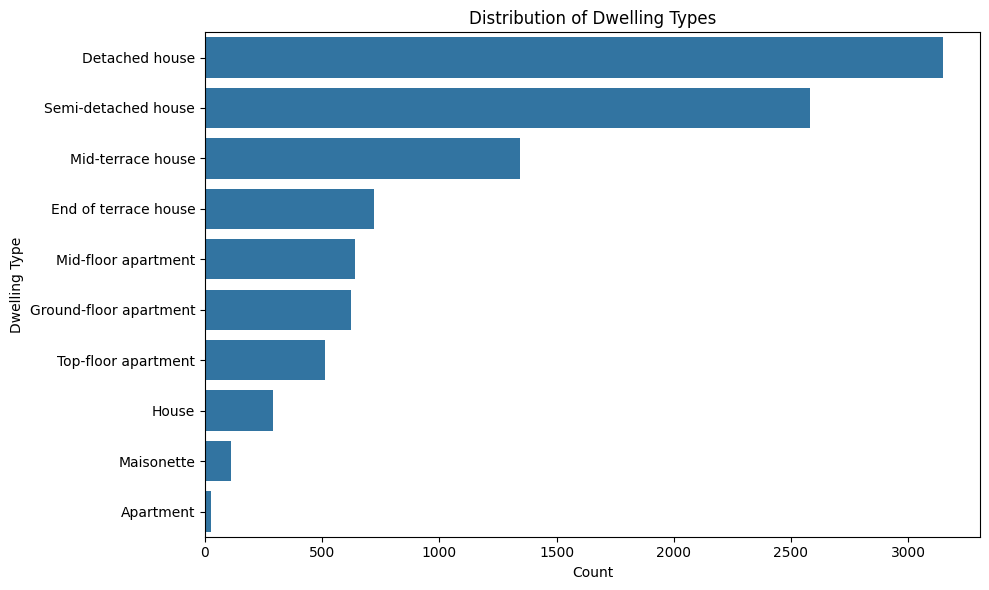

In [ ]:
# Distribution of Dwelling Types

plt.figure(figsize=(10,6))

sns.countplot(
    data=retrofit_df,
    y="DwellingTypeDescr",
    order=retrofit_df["DwellingTypeDescr"].value_counts().index
)

plt.title("Distribution of Dwelling Types")
plt.xlabel("Count")
plt.ylabel("Dwelling Type")

plt.tight_layout()
plt.show()

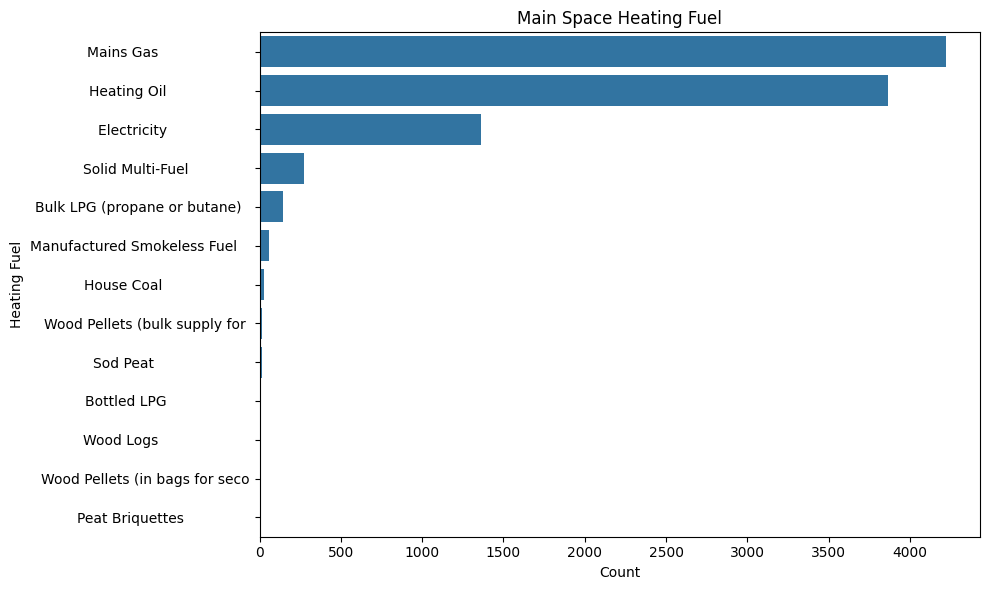

In [ ]:
# Main Space Heating Fuel

plt.figure(figsize=(10,6))

sns.countplot(
    data=retrofit_df,
    y="MainSpaceHeatingFuel",
    order=retrofit_df["MainSpaceHeatingFuel"].value_counts().index
)

plt.title("Main Space Heating Fuel")
plt.xlabel("Count")
plt.ylabel("Heating Fuel")

plt.tight_layout()
plt.show()

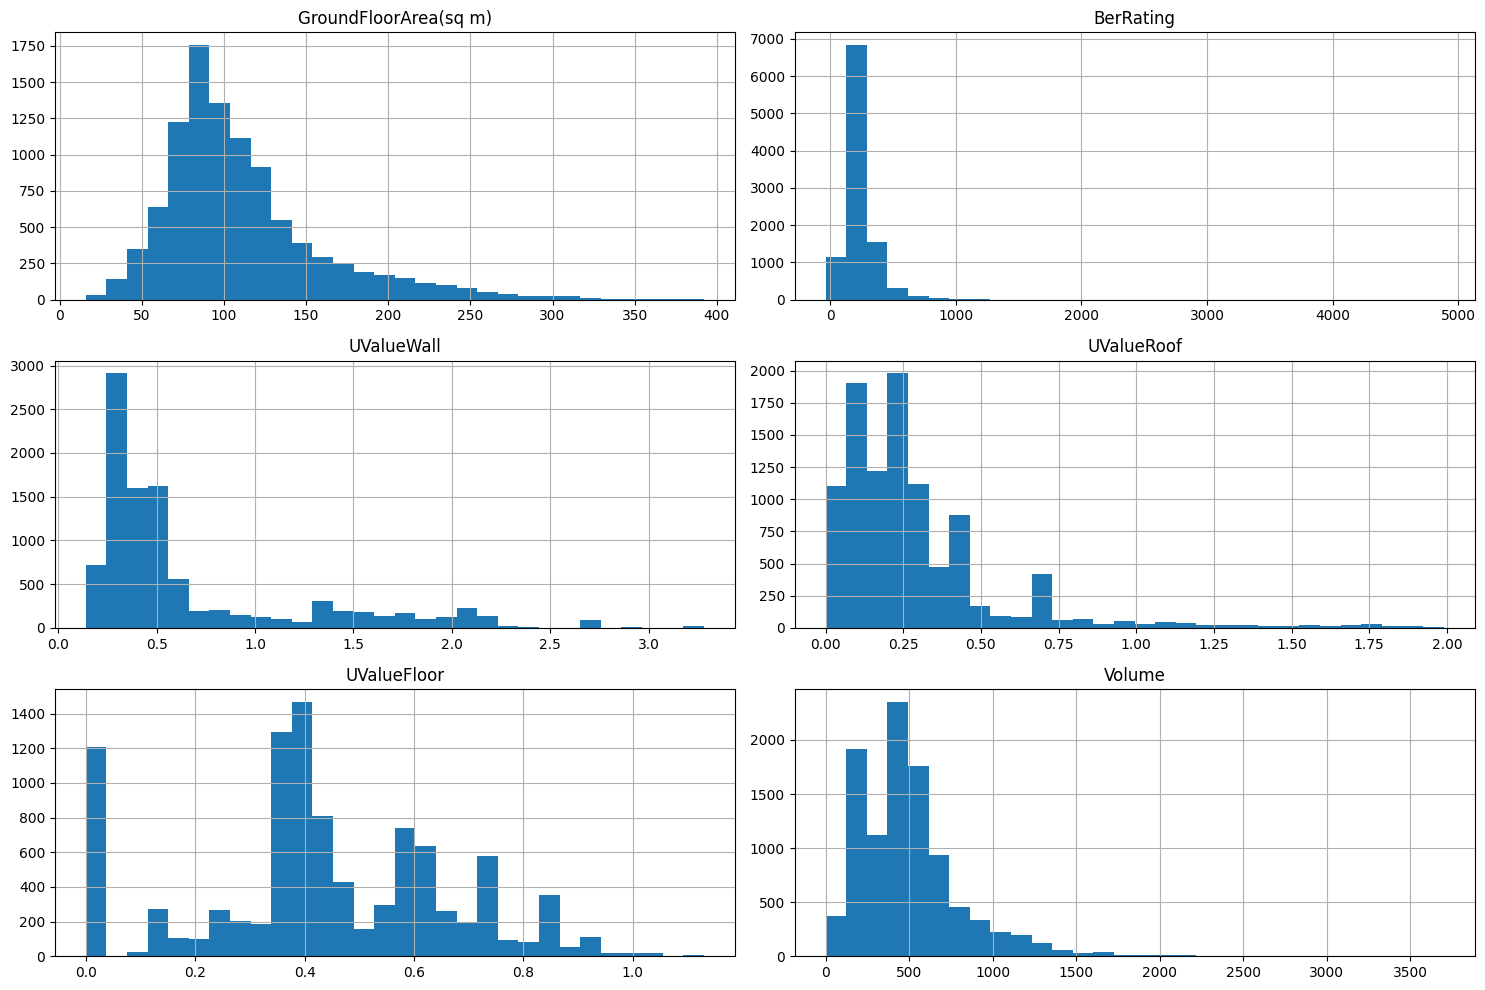

In [ ]:
# Numerical Feature Distributions

numerical_columns = [
    "GroundFloorArea(sq m)",
    "BerRating",
    "UValueWall",
    "UValueRoof",
    "UValueFloor",
    "Volume"
]

retrofit_df[numerical_columns].hist(
    figsize=(15,10),
    bins=30
)

plt.tight_layout()
plt.show()

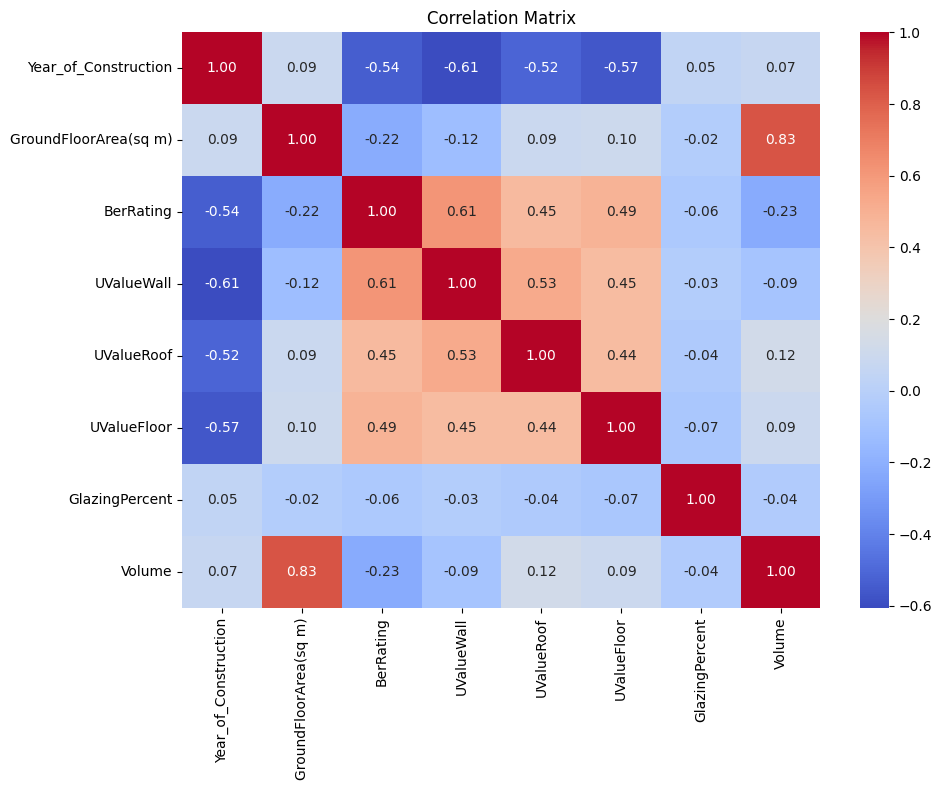

In [ ]:
# Correlation Heatmap

plt.figure(figsize=(10,8))

corr = retrofit_df.select_dtypes(
    include=["int64","float64"]
).corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

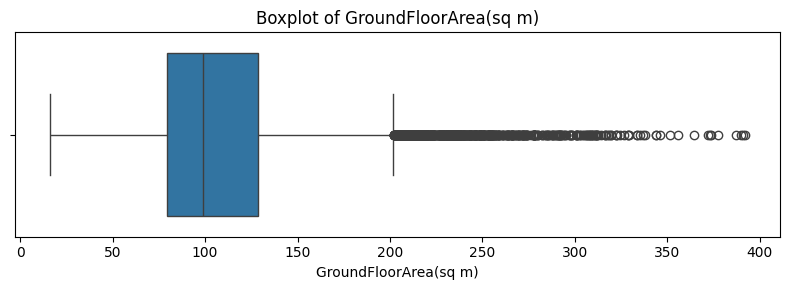

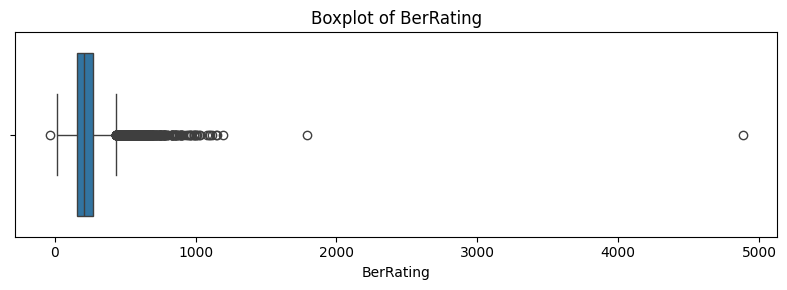

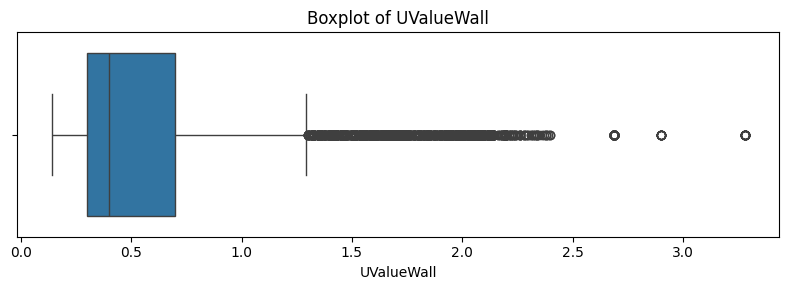

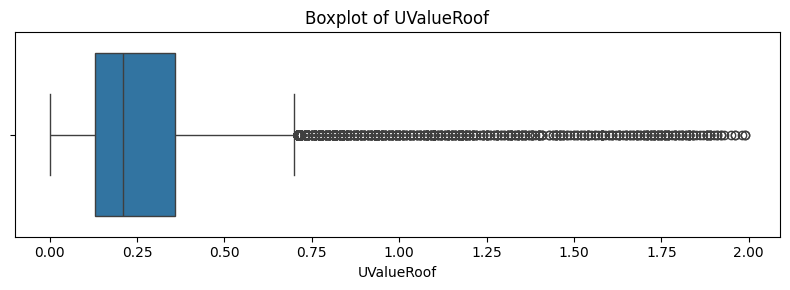

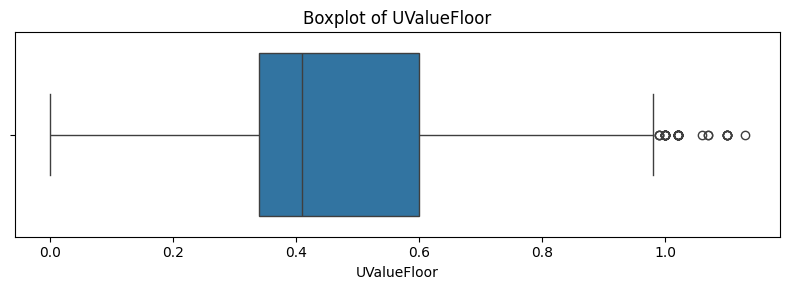

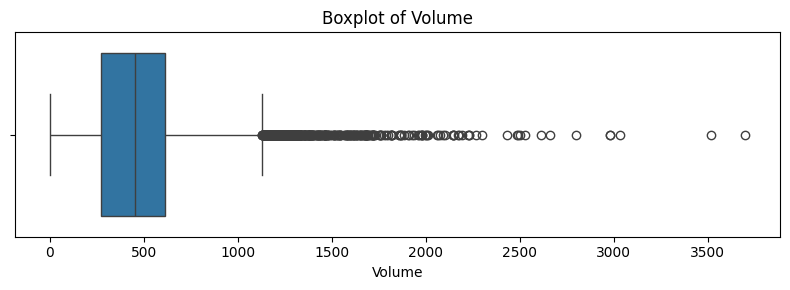

In [ ]:
# Boxplots

numerical_columns = [
    "GroundFloorArea(sq m)",
    "BerRating",
    "UValueWall",
    "UValueRoof",
    "UValueFloor",
    "Volume"
]

for col in numerical_columns:

    plt.figure(figsize=(8,3))

    sns.boxplot(
        x=retrofit_df[col]
    )

    plt.title(f"Boxplot of {col}")

    plt.tight_layout()
    plt.show()

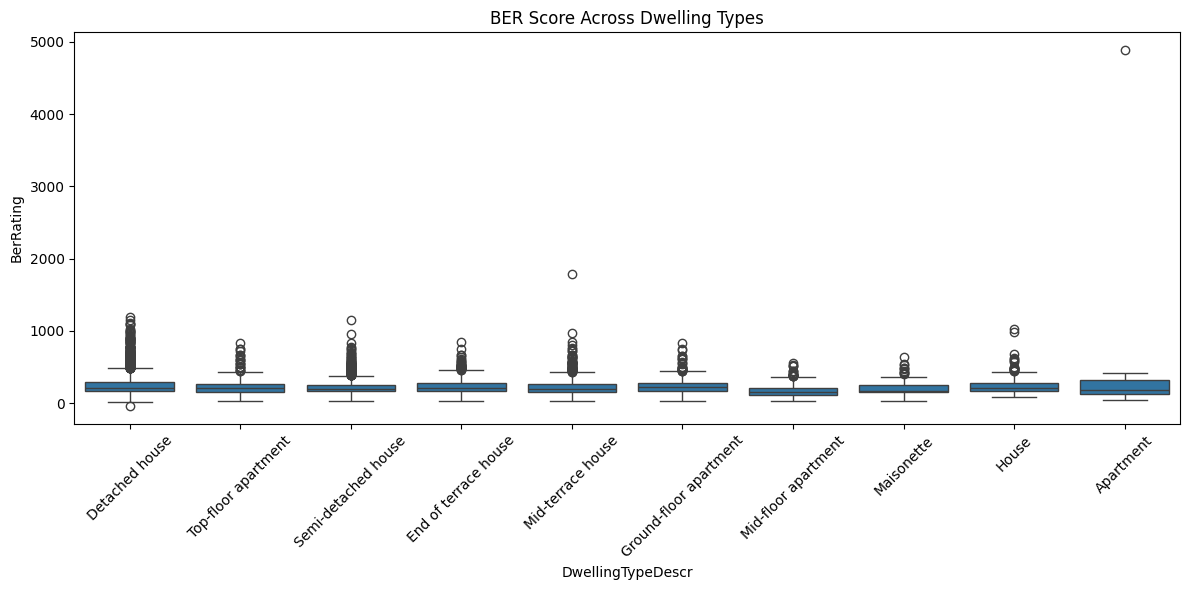

In [ ]:
# BER by Dwelling Type

plt.figure(figsize=(12,6))

sns.boxplot(
    data=retrofit_df,
    x="DwellingTypeDescr",
    y="BerRating"
)

plt.xticks(rotation=45)

plt.title("BER Score Across Dwelling Types")

plt.tight_layout()
plt.show()

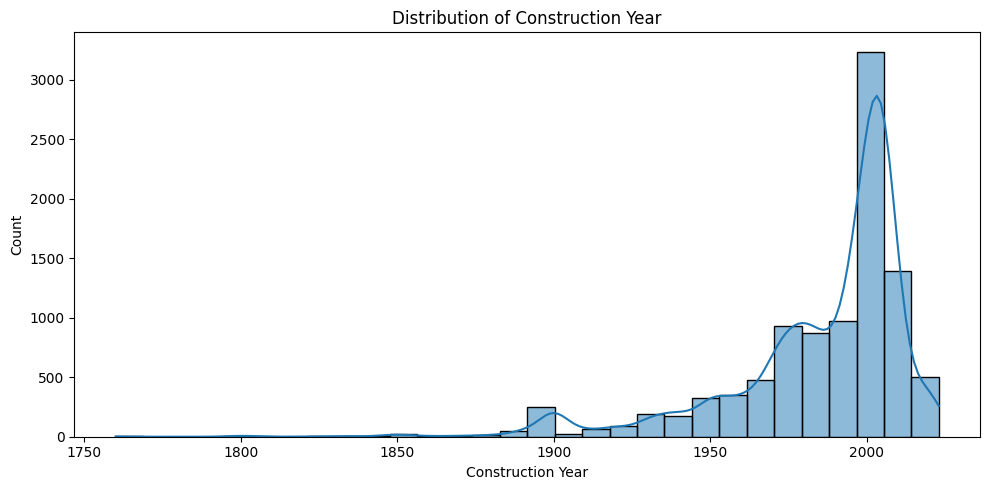

In [ ]:
# Construction Year Distribution

plt.figure(figsize=(10,5))

sns.histplot(
    retrofit_df["Year_of_Construction"],
    bins=30,
    kde=True
)

plt.title("Distribution of Construction Year")

plt.xlabel("Construction Year")

plt.tight_layout()
plt.show()

In [ ]:
# Cap Extreme Values

outlier_columns = [
    "BerRating",
    "GroundFloorArea(sq m)",
    "UValueWall",
    "UValueRoof",
    "UValueFloor",
    "GlazingPercent",
    "Volume"
]

for col in outlier_columns:

    lower = processed_df[col].quantile(0.01)
    upper = processed_df[col].quantile(0.99)

    processed_df[col] = processed_df[col].clip(lower, upper)

print("Extreme values capped using the 1st and 99th percentiles.")

Extreme values capped using the 1st and 99th percentiles.


In [ ]:
# Define State Space

state_features = [
    "DwellingTypeDescr",
    "Year_of_Construction",
    "GroundFloorArea(sq m)",
    "EnergyRating",
    "BerRating",
    "UValueWall",
    "UValueRoof",
    "UValueFloor",
    "MainSpaceHeatingFuel",
    "MainWaterHeatingFuel",
    "ThermalEra",
    "GlazingPercent",
    "Volume"
]

STATE_SIZE = len(state_features)

print("State Features:")
for feature in state_features:
    print("-", feature)

print(f"\nState Dimension: {STATE_SIZE}")

State Features:
- DwellingTypeDescr
- Year_of_Construction
- GroundFloorArea(sq m)
- EnergyRating
- BerRating
- UValueWall
- UValueRoof
- UValueFloor
- MainSpaceHeatingFuel
- MainWaterHeatingFuel
- ThermalEra
- GlazingPercent
- Volume

State Dimension: 13


In [ ]:
# Define Action Space

actions = {
    0: "Do Nothing",
    1: "Attic Insulation",
    2: "Wall Insulation",
    3: "Heat Pump",
    4: "Solar PV"
}

ACTION_SIZE = len(actions)

print("Available Actions")

for key, value in actions.items():
    print(f"{key}: {value}")

print(f"\nTotal Actions: {ACTION_SIZE}")

Available Actions
0: Do Nothing
1: Attic Insulation
2: Wall Insulation
3: Heat Pump
4: Solar PV

Total Actions: 5


In [ ]:
# Retrofit Costs (€)

retrofit_cost = {
    0: 0,
    1: 2500,
    2: 8000,
    3: 14000,
    4: 9000
}

cost_df = pd.DataFrame({

    "Action": list(actions.values()),
    "Cost (€)": list(retrofit_cost.values())

})

display(cost_df)

,Action,Cost (€)
0,Do Nothing,0
1,Attic Insulation,2500
2,Wall Insulation,8000
3,Heat Pump,14000
4,Solar PV,9000


In [ ]:
# Retrofit Effects

retrofit_effect = {

    0: {
        "ber": 0,
        "wall": 0,
        "roof": 0
    },

    1: {
        "ber": -25,
        "wall": 0,
        "roof": -0.15
    },

    2: {
        "ber": -45,
        "wall": -0.25,
        "roof": 0
    },

    3: {
        "ber": -60,
        "wall": 0,
        "roof": 0
    },

    4: {
        "ber": -30,
        "wall": 0,
        "roof": 0
    }

}

print("Retrofit effects created successfully.")

Retrofit effects created successfully.


In [ ]:
class RetrofitEnv(gym.Env):

    metadata = {"render_modes": []}

    ###########################################################
    # Constructor
    ###########################################################

    def __init__(self, data):
        super(RetrofitEnv, self).__init__()

        self.data = data.reset_index(drop=True)

        self.max_steps = 5
        self.initial_budget = 25000
        self.action_space = spaces.Discrete(5)

        self.state_columns = state_features

        self.idx = {
            "dwelling": self.state_columns.index("DwellingTypeDescr"),
            "year": self.state_columns.index("Year_of_Construction"),
            "floor": self.state_columns.index("GroundFloorArea(sq m)"),
            "rating": self.state_columns.index("EnergyRating"),
            "ber": self.state_columns.index("BerRating"),
            "wall": self.state_columns.index("UValueWall"),
            "roof": self.state_columns.index("UValueRoof"),
            "floor_u": self.state_columns.index("UValueFloor"),
            "heating": self.state_columns.index("MainSpaceHeatingFuel"),
            "water": self.state_columns.index("MainWaterHeatingFuel"),
            "thermal": self.state_columns.index("ThermalEra"),
            "glazing": self.state_columns.index("GlazingPercent"),
            "volume": self.state_columns.index("Volume"),
        }

        state_data = self.data[self.state_columns].astype(np.float32)

        # Lower bound floored at 0 since retrofit actions can push
        # wall/roof U-values and BER below the dataset's historical min.
        low_bounds = np.minimum(state_data.min().values, 0.0)

        self.observation_space = spaces.Box(
          low=np.append(low_bounds, 0.0),
          high=np.append(state_data.max().values, self.max_steps),
          dtype=np.float32
        )

        self.completed_actions = set()

        self.reset()

    ###########################################################
    # Reset
    ###########################################################

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.current_house = np.random.randint(0, len(self.data))

        self.state = (
            self.data
            .iloc[self.current_house]
            [self.state_columns]
            .astype(np.float32)
            .values
            .copy()
        )

        self.current_ber = float(self.state[self.idx["ber"]])
        self.current_wall = float(self.state[self.idx["wall"]])
        self.current_roof = float(self.state[self.idx["roof"]])
        self.current_floor = float(self.state[self.idx["floor_u"]])
        self.current_heating = int(self.state[self.idx["heating"]])

        self.remaining_budget = self.initial_budget
        self.current_step = 0
        self.completed_actions = set()

        self.total_cost = 0
        self.total_ber_improvement = 0
        self.total_energy_saving = 0
        self.total_carbon_reduction = 0

        obs = np.append(self.state, self.current_step).astype(np.float32)
        return obs.copy(), {}

    ###########################################################
    # Efficiency Multiplier
    # Scales down (toward 0) the benefit of ANY retrofit action
    # on dwellings that are already efficient (A/B-rated).
    # EnergyRating is assumed encoded ordinally, low = best
    # (e.g. A1=0, A2=1, A3=2, B1=3, B2=4, B3=5, ...).
    ###########################################################

    def efficiency_multiplier(self):
        rating = float(self.state[self.idx["rating"]])

        if rating <= 2:      # A1-A3
            return 0.05
        elif rating <= 5:    # B1-B3
            return 0.30
        elif rating <= 7:    # C1-C2
            return 0.70
        else:
            return 1.0

    ###########################################################
    # BER Improvement
    # Now driven directly by how poor the relevant characteristic
    # actually is, rather than just its rank vs static thresholds.
    ###########################################################

    def calculate_ber_improvement(self, action):
        improvement = 0

        #######################################################
        # Attic Insulation — scaled by how bad current_roof is
        #######################################################

        if action == 1:
            if self.current_roof > 0.50:
                improvement = 30
            elif self.current_roof > 0.30:
                improvement = 18
            elif self.current_roof > 0.15:
                improvement = 8
            else:
                improvement = 2  # roof already good, little benefit

        #######################################################
        # Wall Insulation — scaled by how bad current_wall is
        #######################################################

        elif action == 2:
            if self.current_wall > 1.00:
                improvement = 45
            elif self.current_wall > 0.60:
                improvement = 28
            elif self.current_wall > 0.35:
                improvement = 12
            else:
                improvement = 3  # wall already good, little benefit

        #######################################################
        # Heat Pump — scaled by how dirty/inefficient current fuel is
        #######################################################

        elif action == 3:
            if self.current_heating in [6, 7, 8, 9]:
                improvement = 55
            elif self.current_heating in [3, 4, 5]:
                improvement = 30
            else:
                improvement = 10  # already low-carbon heating

        #######################################################
        # Solar PV — scaled inversely to current BER
        # (worse BER = more headroom for PV to matter)
        #######################################################

        elif action == 4:
            if self.current_ber > 300:
                improvement = 30
            elif self.current_ber > 150:
                improvement = 18
            else:
                improvement = 6  # already efficient, PV adds little

        # Apply the dwelling-level efficiency multiplier so retrofits
        # on already A/B-rated homes are strongly discounted.
        improvement *= self.efficiency_multiplier()

        return improvement

    ###########################################################
    # Energy Saving
    ###########################################################

    def calculate_energy_saving(self, action):
    # Energy saving now depends on dwelling size (Volume), not just BER gain —
    # insulating a large house saves more absolute energy than a small one
    # for the same U-value improvement.
      ber_gain = self.calculate_ber_improvement(action)
      volume = float(self.state[self.idx["volume"]])
      size_factor = max(0.5, min(2.0, volume / 500.0))  # normalize around a 500 m3 reference
      return ber_gain * 0.85 * size_factor

    ###########################################################
    # Carbon Reduction
    ###########################################################

    def calculate_carbon_reduction(self, action):
    # Carbon reduction now depends on which fuel is actually being displaced —
    # switching a solid-fuel/oil heated home carries a much higher carbon
    # factor per unit energy than switching an already-gas/electric home.
      ber_gain = self.calculate_ber_improvement(action)

      high_carbon_fuels = [6, 7, 8, 9]  # VERIFY against label_encoders["MainSpaceHeatingFuel"].classes_

      if action == 3:  # Heat Pump directly displaces the heating fuel
        carbon_factor = 1.10 if self.current_heating in high_carbon_fuels else 0.50
      else:
        carbon_factor = 0.60

      return ber_gain * carbon_factor

    ###########################################################
    # Update Building State
    ###########################################################

    def update_state(self, action):
        if action == 1:
            self.current_roof = max(0.10, self.current_roof * 0.45)

        elif action == 2:
            self.current_wall = max(0.20, self.current_wall * 0.40)

        elif action == 3:
            self.current_heating = 0

        elif action == 4:
            self.current_ber *= 0.95

        ber_gain = self.calculate_ber_improvement(action)
        self.current_ber = max(0, self.current_ber - ber_gain)

        self.state[self.idx["ber"]] = self.current_ber
        self.state[self.idx["wall"]] = self.current_wall
        self.state[self.idx["roof"]] = self.current_roof
        self.state[self.idx["heating"]] = self.current_heating

    ###########################################################
    # Reward Function
    ###########################################################

    def calculate_reward(self, action):
        ber_gain = self.calculate_ber_improvement(action)
        energy_gain = self.calculate_energy_saving(action)
        carbon_gain = self.calculate_carbon_reduction(action)
        cost = retrofit_cost[action]

        reward = (
            0.45 * ber_gain +
            0.35 * energy_gain +
            0.20 * carbon_gain -
            cost / 3500
        )

        return reward, ber_gain, energy_gain, carbon_gain
    ###########################################################
    # Step Function
    ###########################################################

    def step(self, action):
        reward = 0
        terminated = False
        truncated = False

        if action == 0:
          # Passive degradation: an untouched dwelling doesn't hold its BER
          # perfectly flat — wear, aging systems, etc. add a small annual penalty,
          # so delaying retrofits has a real cost, not just a flat -1 reward.
          degradation = 2.0
          self.current_ber += degradation
          self.state[self.idx["ber"]] = self.current_ber
          reward = -1

        elif action in self.completed_actions:
            reward = -15
        elif retrofit_cost[action] > self.remaining_budget:
            reward = -15

        else:
            cost = retrofit_cost[action]
            self.remaining_budget -= cost
            self.total_cost += cost

            reward, ber_gain, energy_gain, carbon_gain = self.calculate_reward(action)

            self.update_state(action)

            self.total_ber_improvement += ber_gain
            self.total_energy_saving += energy_gain
            self.total_carbon_reduction += carbon_gain

            self.completed_actions.add(action)


            #######################################################
            # Pacing incentive: discourage front-loading every
            # retrofit into the first year(s) then coasting on
            # "Do Nothing". Penalize taking more than one valid
            # retrofit action within the same step-year cluster by
            # comparing actions-taken-so-far to steps-elapsed-so-far.
            # If the agent has already done more retrofits than
            # years elapsed, it's front-loading — shrink the reward.
            #######################################################

            actions_taken = len(self.completed_actions)
            years_elapsed = self.current_step + 1  # +1 since step hasn't advanced yet

            if actions_taken > years_elapsed:
              pacing_penalty = 2 * (actions_taken - years_elapsed)
              reward -= pacing_penalty

        self.current_step += 1

        if self.current_step >= self.max_steps:
            terminated = True

        observation = np.append(self.state, self.current_step).astype(np.float32)

        info = {
            "Current Year": self.current_step,
            "Remaining Budget": round(self.remaining_budget, 2),
            "Budget Used": round(self.total_cost, 2),
            "BER Improvement": round(self.total_ber_improvement, 2),
            "Energy Saving": round(self.total_energy_saving, 2),
            "Carbon Reduction": round(self.total_carbon_reduction, 2),
            "Completed Retrofits": len(self.completed_actions)
        }

        return observation, float(reward), terminated, truncated, info

In [ ]:
# Validate Environment

env = RetrofitEnv(processed_df)

check_env(env)

print("Environment validated successfully.")

Environment validated successfully.


In [ ]:
# Test Environment

state, info = env.reset()

print("Initial State\n")
print(state)

done = False

total_reward = 0

while not done:

    action = env.action_space.sample()

    state, reward, done, truncated, info = env.step(action)

    total_reward += reward

    print("-" * 50)
    print("Action:", actions[action])
    print("Reward:", round(reward, 2))
    print("Remaining Budget:", info["Remaining Budget"])

print("\nEpisode Finished")
print("Total Reward:", round(total_reward, 2))

Initial State

[ 7.         -1.0168     -0.44699827 11.          0.7240241   1.5967791
  0.60003936 -0.05851301  5.          5.          1.          0.12126087
 -0.15236956  0.        ]
--------------------------------------------------
Action: Heat Pump
Reward: 16.96
Remaining Budget: 11000
--------------------------------------------------
Action: Solar PV
Reward: 1.74
Remaining Budget: 2000
--------------------------------------------------
Action: Heat Pump
Reward: -15.0
Remaining Budget: 2000
--------------------------------------------------
Action: Attic Insulation
Reward: -15.0
Remaining Budget: 2000
--------------------------------------------------
Action: Heat Pump
Reward: -15.0
Remaining Budget: 2000

Episode Finished
Total Reward: -26.3


In [ ]:
# Create Deep Q-Network (DQN)

from stable_baselines3 import DQN

dqn_model = DQN(

    policy="MlpPolicy",

    env=env,

    learning_rate=0.0005,

    buffer_size=20000,

    learning_starts=1000,

    batch_size=64,

    gamma=0.99,

    tau=1.0,

    train_freq=4,

    gradient_steps=1,

    target_update_interval=500,

    exploration_fraction=0.30,

    exploration_initial_eps=1.0,

    exploration_final_eps=0.05,

    verbose=1,

    seed=42

)

print("DQN model created successfully.")

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
DQN model created successfully.


In [ ]:
# DQN Hyperparameter Configuration

parameter_df = pd.DataFrame({

    "Hyperparameter": [
        "Policy Network",
        "Learning Rate",
        "Replay Buffer Size",
        "Learning Starts",
        "Batch Size",
        "Discount Factor (Gamma)",
        "Target Update Interval",
        "Training Frequency",
        "Exploration Fraction",
        "Initial Epsilon",
        "Final Epsilon",
        "Total Training Timesteps"
    ],

    "Value": [
        "MLP",
        0.0005,
        20000,
        1000,
        64,
        0.99,
        500,
        4,
        0.30,
        1.00,
        0.05,
        25000
    ]

})

display(parameter_df)

,Hyperparameter,Value
0,Policy Network,MLP
1,Learning Rate,0.0005
2,Replay Buffer Size,20000
3,Learning Starts,1000
4,Batch Size,64
5,Discount Factor (Gamma),0.99
6,Target Update Interval,500
7,Training Frequency,4
8,Exploration Fraction,0.3
9,Initial Epsilon,1.0


In [ ]:
# Train the Deep Q-Network (DQN)

import time

TOTAL_TIMESTEPS = 25000

print("Training the DQN Agent...")

start_time = time.time()

dqn_model.learn(
    total_timesteps=TOTAL_TIMESTEPS,
    progress_bar=True
)

end_time = time.time()

training_time = end_time - start_time

print("\nTraining Completed Successfully!")
print(f"Training Time: {training_time:.2f} seconds")
print(f"Total Timesteps: {TOTAL_TIMESTEPS}")

Output()

Streaming output truncated to the last 5000 lines.
| train/              |          |
|    learning_rate    | 0.0005   |
|    loss             | 1.84     |
|    n_updates        | 4334     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 5        |
|    ep_rew_mean      | 11.5     |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 3672     |
|    fps              | 699      |
|    time_elapsed     | 26       |
|    total_timesteps  | 18360    |
| train/              |          |
|    learning_rate    | 0.0005   |
|    loss             | 2.13     |
|    n_updates        | 4339     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 5        |
|    ep_rew_mean      | 10.9     |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 3676     |
|   


Training Completed Successfully!
Training Time: 36.40 seconds
Total Timesteps: 25000


In [ ]:
# Training Summary

training_summary = pd.DataFrame({

    "Metric":[
        "Training Timesteps",
        "Training Time (Seconds)",
        "Average Time per 1000 Timesteps (Seconds)"
    ],

    "Value":[
        TOTAL_TIMESTEPS,
        round(training_time,2),
        round(training_time/(TOTAL_TIMESTEPS/1000),2)
    ]

})

display(training_summary)

,Metric,Value
0,Training Timesteps,25000.00
1,Training Time (Seconds),36.40
2,Average Time per 1000 Timesteps (Seconds),1.46


In [ ]:
# Save the Trained DQN Model

MODEL_NAME = "RETROFIT_DRL_DQN"

dqn_model.save(MODEL_NAME)

print(f"Model saved as '{MODEL_NAME}.zip'")

Model saved as 'RETROFIT_DRL_DQN.zip'


In [ ]:
# Quick Test of the Trained Agent

test_env = RetrofitEnv(processed_df)

state, info = test_env.reset()

done = False

total_reward = 0

selected_actions = []

while not done:

    action, _ = dqn_model.predict(
        state,
        deterministic=True
    )

    selected_actions.append(actions[int(action)])

    state, reward, done, truncated, info = test_env.step(int(action))

    total_reward += reward

print("Recommended Multi-Year Retrofit Pathway")

for year, action in enumerate(selected_actions, start=1):
    print(f"Year {year}: {action}")

print("\nTotal Reward:", round(total_reward,2))
print("Remaining Budget (€):", info["Remaining Budget"])
print("BER Improvement:", round(info["BER Improvement"],2))
print("Energy Saving:", round(info["Energy Saving"],2))
print("Carbon Reduction:", round(info["Carbon Reduction"],2))

Recommended Multi-Year Retrofit Pathway
Year 1: Solar PV
Year 2: Heat Pump
Year 3: Do Nothing
Year 4: Do Nothing
Year 5: Do Nothing

Total Reward: 1.73
Remaining Budget (€): 2000
BER Improvement: 16.0
Energy Saving: 6.8
Carbon Reduction: 8.6


In [ ]:
# Policy Evaluation Function

def evaluate_policy(env, model=None, policy="dqn", episodes=100):

    rewards = []
    ber_scores = []
    energy_scores = []
    carbon_scores = []
    budgets = []

    for _ in range(episodes):

        state, info = env.reset()

        done = False
        total_reward = 0

        while not done:

            if policy == "random":

                action = env.action_space.sample()

            elif policy == "greedy":
              # Highest priority retrofit that is both unused AND affordable
              priority = [3, 2, 1, 4]
              action = 0  # fallback: Do Nothing
              for a in priority:
                  if a not in env.completed_actions and retrofit_cost[a] <= env.remaining_budget:
                    action = a
                    break

            elif policy == "dqn":

                action, _ = model.predict(
                    state,
                    deterministic=True
                )

                action = int(action)

            state, reward, done, truncated, info = env.step(action)

            total_reward += reward

        rewards.append(total_reward)

        ber_scores.append(info["BER Improvement"])

        energy_scores.append(info["Energy Saving"])

        carbon_scores.append(info["Carbon Reduction"])

        budgets.append(info["Remaining Budget"])

    return {

        "Reward": np.mean(rewards),

        "BER Improvement": np.mean(ber_scores),

        "Energy Saving": np.mean(energy_scores),

        "Carbon Reduction": np.mean(carbon_scores),

        "Remaining Budget": np.mean(budgets)

    }

In [ ]:
# Evaluate Policies

random_results = evaluate_policy(

    RetrofitEnv(processed_df),

    policy="random"

)

greedy_results = evaluate_policy(

    RetrofitEnv(processed_df),

    policy="greedy"

)

dqn_results = evaluate_policy(

    RetrofitEnv(processed_df),

    model=dqn_model,

    policy="dqn"

)

comparison_df = pd.DataFrame({

    "Metric":[

        "Average Reward",

        "BER Improvement",

        "Energy Saving",

        "Carbon Reduction",

        "Remaining Budget (€)"

    ],

    "Random":[

        random_results["Reward"],

        random_results["BER Improvement"],

        random_results["Energy Saving"],

        random_results["Carbon Reduction"],

        random_results["Remaining Budget"]

    ],

    "Greedy":[

        greedy_results["Reward"],

        greedy_results["BER Improvement"],

        greedy_results["Energy Saving"],

        greedy_results["Carbon Reduction"],

        greedy_results["Remaining Budget"]

    ],

    "DQN":[

        dqn_results["Reward"],

        dqn_results["BER Improvement"],

        dqn_results["Energy Saving"],

        dqn_results["Carbon Reduction"],

        dqn_results["Remaining Budget"]

    ]

})

display(comparison_df)

,Metric,Random,Greedy,DQN
0,Average Reward,-12.573179,14.987822,15.033906
1,BER Improvement,25.569500,33.630500,32.779000
2,Energy Saving,10.866800,14.293000,13.931600
3,Carbon Reduction,14.499700,19.257800,18.737400
4,Remaining Budget (€),6090.000000,500.000000,7745.000000


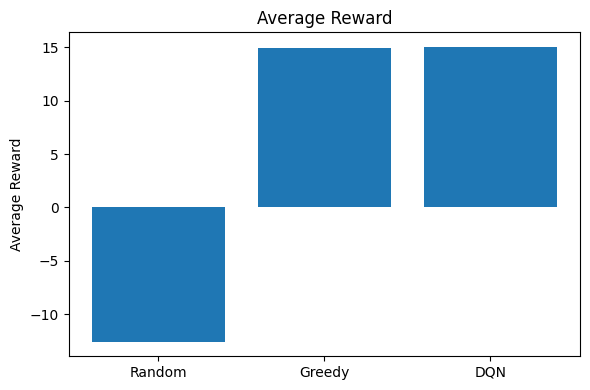

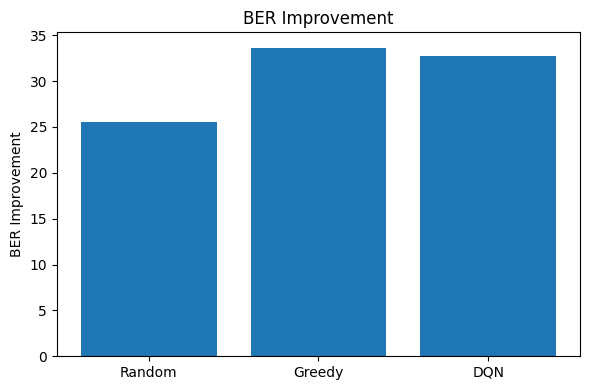

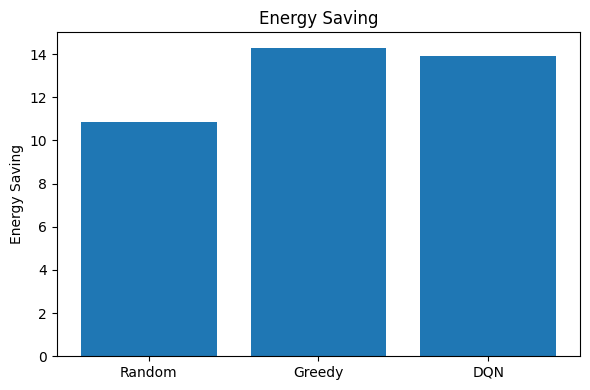

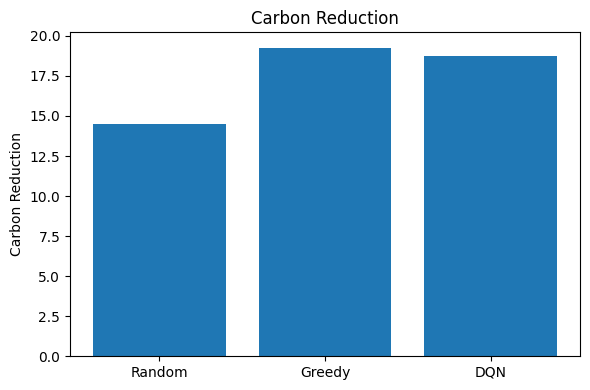

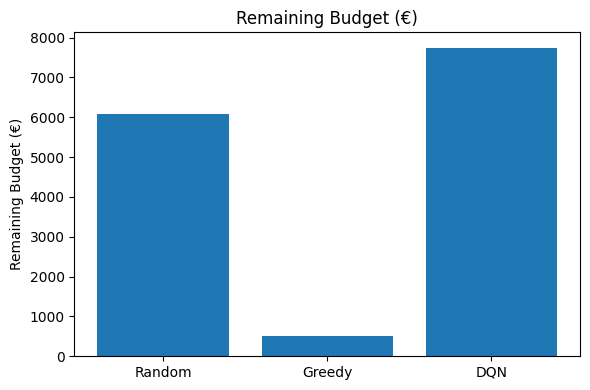

In [ ]:
# Policy Performance Comparison

metrics = comparison_df["Metric"]

for metric in metrics:

    values = comparison_df.loc[
        comparison_df["Metric"] == metric,
        ["Random","Greedy","DQN"]
    ].values.flatten()

    plt.figure(figsize=(6,4))

    plt.bar(

        ["Random","Greedy","DQN"],

        values

    )

    plt.title(metric)

    plt.ylabel(metric)

    plt.tight_layout()

    plt.show()

In [ ]:
# Best Performing Policy

summary = comparison_df.copy()

summary["Best Policy"] = summary[
    ["Random","Greedy","DQN"]
].idxmax(axis=1)

display(summary)

,Metric,Random,Greedy,DQN,Best Policy
0,Average Reward,-12.573179,14.987822,15.033906,DQN
1,BER Improvement,25.569500,33.630500,32.779000,Greedy
2,Energy Saving,10.866800,14.293000,13.931600,Greedy
3,Carbon Reduction,14.499700,19.257800,18.737400,Greedy
4,Remaining Budget (€),6090.000000,500.000000,7745.000000,DQN


In [ ]:
# Scenario-Based Simulation

def simulate_budget_scenario(model, data, budget, episodes=50):

    env = RetrofitEnv(data)
    env.initial_budget = budget

    rewards = []
    ber = []
    energy = []
    carbon = []
    remaining = []
    actions_taken = []

    for _ in range(episodes):

        state, info = env.reset()

        done = False
        total_reward = 0

        while not done:

            action, _ = model.predict(
                state,
                deterministic=True
            )

            action = int(action)

            actions_taken.append(actions[action])

            state, reward, done, truncated, info = env.step(action)

            total_reward += reward

        rewards.append(total_reward)
        ber.append(info["BER Improvement"])
        energy.append(info["Energy Saving"])
        carbon.append(info["Carbon Reduction"])
        remaining.append(info["Remaining Budget"])

    return {

        "Budget (€)": budget,

        "Average Reward": np.mean(rewards),

        "Average BER Improvement": np.mean(ber),

        "Average Energy Saving": np.mean(energy),

        "Average Carbon Reduction": np.mean(carbon),

        "Average Remaining Budget": np.mean(remaining),

        "Most Recommended Action": pd.Series(actions_taken).mode()[0]

    }

In [ ]:
# Run Budget Scenarios

scenario_results = []

budgets = [

    10000,
    25000,
    40000

]

for budget in budgets:

    result = simulate_budget_scenario(

        dqn_model,

        processed_df,

        budget

    )

    scenario_results.append(result)

scenario_df = pd.DataFrame(scenario_results)

display(scenario_df)

,Budget (€),Average Reward,Average BER Improvement,Average Energy Saving,Average Carbon Reduction,Average Remaining Budget,Most Recommended Action
0,10000,-44.075982,13.060,5.5488,7.836,6350.0,Heat Pump
1,25000,13.672167,30.175,12.8248,16.753,9300.0,Do Nothing
2,40000,15.923870,33.750,14.3442,18.766,22930.0,Do Nothing


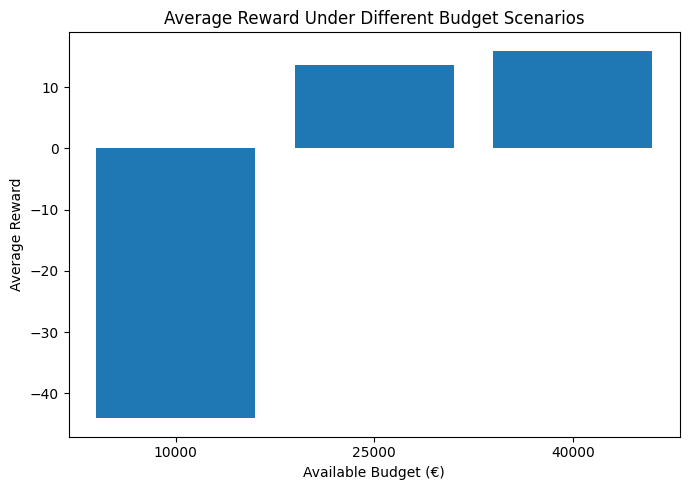

In [ ]:
# Reward Comparison

plt.figure(figsize=(7,5))

plt.bar(

    scenario_df["Budget (€)"].astype(str),

    scenario_df["Average Reward"]

)

plt.title("Average Reward Under Different Budget Scenarios")

plt.xlabel("Available Budget (€)")

plt.ylabel("Average Reward")

plt.tight_layout()

plt.show()

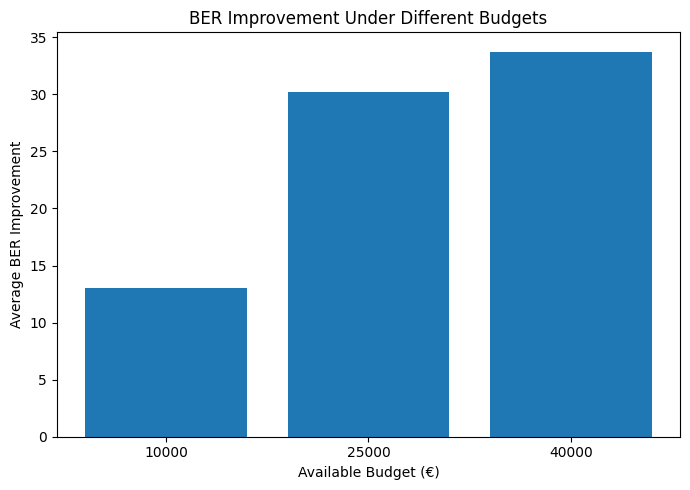

In [ ]:
# BER Improvement Comparison

plt.figure(figsize=(7,5))

plt.bar(

    scenario_df["Budget (€)"].astype(str),

    scenario_df["Average BER Improvement"]

)

plt.title("BER Improvement Under Different Budgets")

plt.xlabel("Available Budget (€)")

plt.ylabel("Average BER Improvement")

plt.tight_layout()

plt.show()

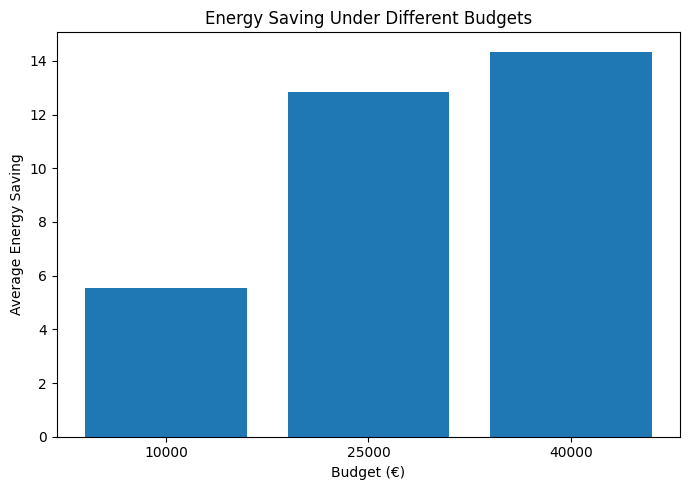

In [ ]:
# Energy Saving Comparison

plt.figure(figsize=(7,5))

plt.bar(

    scenario_df["Budget (€)"].astype(str),

    scenario_df["Average Energy Saving"]

)

plt.title("Energy Saving Under Different Budgets")

plt.xlabel("Budget (€)")

plt.ylabel("Average Energy Saving")

plt.tight_layout()

plt.show()

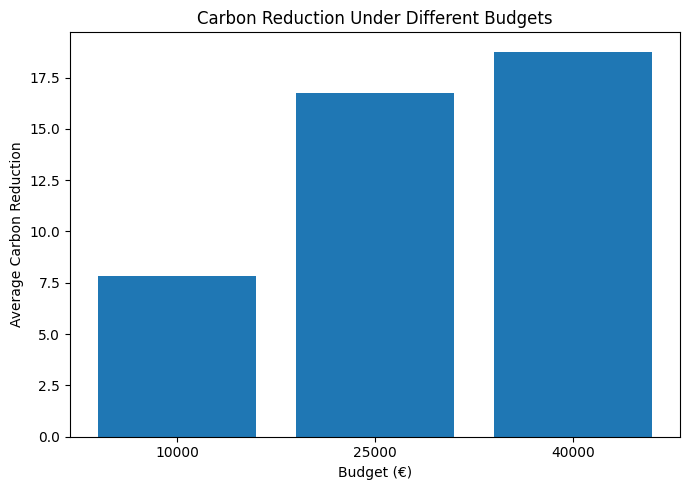

In [ ]:
# Carbon Reduction Comparison

plt.figure(figsize=(7,5))

plt.bar(

    scenario_df["Budget (€)"].astype(str),

    scenario_df["Average Carbon Reduction"]

)

plt.title("Carbon Reduction Under Different Budgets")

plt.xlabel("Budget (€)")

plt.ylabel("Average Carbon Reduction")

plt.tight_layout()

plt.show()

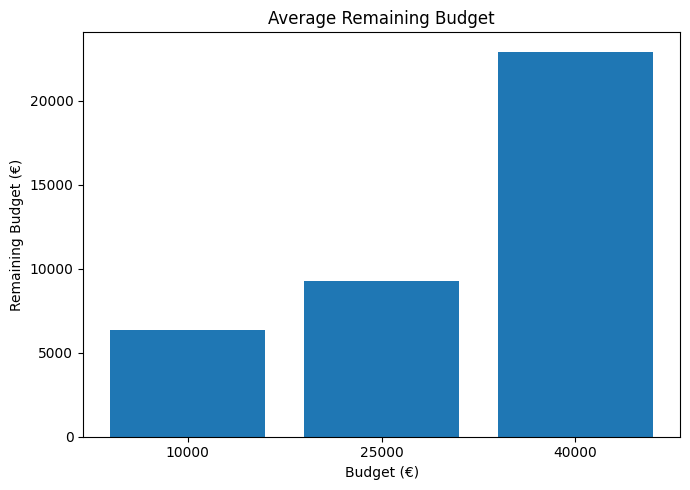

In [ ]:
# Remaining Budget Comparison

plt.figure(figsize=(7,5))

plt.bar(

    scenario_df["Budget (€)"].astype(str),

    scenario_df["Average Remaining Budget"]

)

plt.title("Average Remaining Budget")

plt.xlabel("Budget (€)")

plt.ylabel("Remaining Budget (€)")

plt.tight_layout()

plt.show()

In [ ]:
# Scenario Summary

scenario_summary = scenario_df.copy()

scenario_summary = scenario_summary.round(2)

display(scenario_summary)

,Budget (€),Average Reward,Average BER Improvement,Average Energy Saving,Average Carbon Reduction,Average Remaining Budget,Most Recommended Action
0,10000,-44.08,13.06,5.55,7.84,6350.0,Heat Pump
1,25000,13.67,30.18,12.82,16.75,9300.0,Do Nothing
2,40000,15.92,33.75,14.34,18.77,22930.0,Do Nothing


In [ ]:
# Generate Optimal Retrofit Pathway

def generate_retrofit_pathway(model, data, budget=25000):

    env = RetrofitEnv(data)
    env.initial_budget = budget

    state, info = env.reset()

    pathway = []

    done = False
    year = 1

    while not done:

        action, _ = model.predict(
            state,
            deterministic=True
        )

        action = int(action)

        state, reward, done, truncated, info = env.step(action)

        pathway.append({

            "Year": year,
            "Retrofit Action": actions[action],
            "Reward": round(reward,2),
            "Remaining Budget (€)": info["Remaining Budget"],
            "Cumulative BER Improvement": round(info["BER Improvement"],2),
            "Cumulative Energy Saving": round(info["Energy Saving"],2),
            "Cumulative Carbon Reduction": round(info["Carbon Reduction"],2)

        })

        year += 1

    return pd.DataFrame(pathway)

In [ ]:
# Generate Recommendations

NUMBER_OF_DWELLINGS = 5

sample_indices = np.random.choice(
    processed_df.index,
    NUMBER_OF_DWELLINGS,
    replace=False
)

recommendations = {}

for i, idx in enumerate(sample_indices):

    print("="*80)
    print(f"IRISH DWELLING {i+1}")
    print("="*80)

    dwelling = retrofit_df.loc[[idx]]

    display(dwelling)

    pathway = generate_retrofit_pathway(

        dqn_model,

        processed_df.loc[[idx]],

        budget=25000

    )

    recommendations[f"Dwelling_{i+1}"] = pathway

    display(pathway)

IRISH DWELLING 1


,DwellingTypeDescr,Year_of_Construction,GroundFloorArea(sq m),EnergyRating,BerRating,UValueWall,UValueRoof,UValueFloor,MainSpaceHeatingFuel,MainWaterHeatingFuel,ThermalEra,GlazingPercent,Volume
8123,Detached house,1989,102.59,D1,236.02,1.35,0.43,0.48,Heating Oil,Heating Oil,Post,0.223275,255.4491


,Year,Retrofit Action,Reward,Remaining Budget (€),Cumulative BER Improvement,Cumulative Energy Saving,Cumulative Carbon Reduction
0,1,Wall Insulation,30.06,17000,45.0,19.12,27.0
1,2,Heat Pump,16.96,3000,75.0,31.88,42.0
2,3,Do Nothing,-1.00,3000,75.0,31.88,42.0
3,4,Do Nothing,-1.00,3000,75.0,31.88,42.0
4,5,Do Nothing,-1.00,3000,75.0,31.88,42.0


IRISH DWELLING 2


,DwellingTypeDescr,Year_of_Construction,GroundFloorArea(sq m),EnergyRating,BerRating,UValueWall,UValueRoof,UValueFloor,MainSpaceHeatingFuel,MainWaterHeatingFuel,ThermalEra,GlazingPercent,Volume
1176,Mid-terrace house,2002,95.07,C3,214.62,0.55,0.27,0.29,Mains Gas,Mains Gas,Post,0.271127,490.5612


...

,DwellingTypeDescr,Year_of_Construction,GroundFloorArea(sq m),EnergyRating,BerRating,UValueWall,UValueRoof,UValueFloor,MainSpaceHeatingFuel,MainWaterHeatingFuel,ThermalEra,GlazingPercent,Volume
7041,Detached house,1980,72.78,G,552.89,0.54,0.5,0.64,Solid Multi-Fuel,Solid Multi-Fuel,Post,0.120553,178.311


,Year,Retrofit Action,Reward,Remaining Budget (€),Cumulative BER Improvement,Cumulative Energy Saving,Cumulative Carbon Reduction
0,1,Wall Insulation,-0.13,17000,3.0,1.27,1.8
1,2,Heat Pump,41.03,3000,58.0,24.65,62.3
2,3,Do Nothing,-1.00,3000,58.0,24.65,62.3
3,4,Do Nothing,-1.00,3000,58.0,24.65,62.3
4,5,Do Nothing,-1.00,3000,58.0,24.65,62.3


IRISH DWELLING 5


,DwellingTypeDescr,Year_of_Construction,GroundFloorArea(sq m),EnergyRating,BerRating,UValueWall,UValueRoof,UValueFloor,MainSpaceHeatingFuel,MainWaterHeatingFuel,ThermalEra,GlazingPercent,Volume
493,Top-floor apartment,2007,55.06,C1,164.96,0.85,0.21,0.0,Mains Gas,Mains Gas,Post,0.137424,134.3464


,Year,Retrofit Action,Reward,Remaining Budget (€),Cumulative BER Improvement,Cumulative Energy Saving,Cumulative Carbon Reduction
0,1,Wall Insulation,-0.78,17000,2.1,0.89,1.26
1,2,Heat Pump,10.67,3000,23.1,9.82,11.76
2,3,Do Nothing,-1.00,3000,23.1,9.82,11.76
3,4,Do Nothing,-1.00,3000,23.1,9.82,11.76
4,5,Do Nothing,-1.00,3000,23.1,9.82,11.76


In [ ]:
# Recommendation Summary

summary = []

for dwelling, pathway in recommendations.items():

    final = pathway.iloc[-1]

    summary.append({

        "Dwelling": dwelling,

        "Final BER Improvement": final["Cumulative BER Improvement"],

        "Final Energy Saving": final["Cumulative Energy Saving"],

        "Final Carbon Reduction": final["Cumulative Carbon Reduction"],

        "Remaining Budget (€)": final["Remaining Budget (€)"]

    })

summary_df = pd.DataFrame(summary)

display(summary_df)

,Dwelling,Final BER Improvement,Final Energy Saving,Final Carbon Reduction,Remaining Budget (€)
0,Dwelling_1,75.0,31.88,42.00,3000
1,Dwelling_2,32.0,13.60,16.20,8500
2,Dwelling_3,58.0,24.65,62.30,3000
3,Dwelling_4,58.0,24.65,62.30,3000
4,Dwelling_5,23.1,9.82,11.76,3000


In [ ]:
# Recommended Retrofit Frequency

recommended_actions = []

for pathway in recommendations.values():

    recommended_actions.extend(
        pathway["Retrofit Action"].tolist()
    )

action_frequency = pd.Series(
    recommended_actions
).value_counts()

display(action_frequency)

,count
Do Nothing,15
Heat Pump,5
Wall Insulation,4
Attic Insulation,1


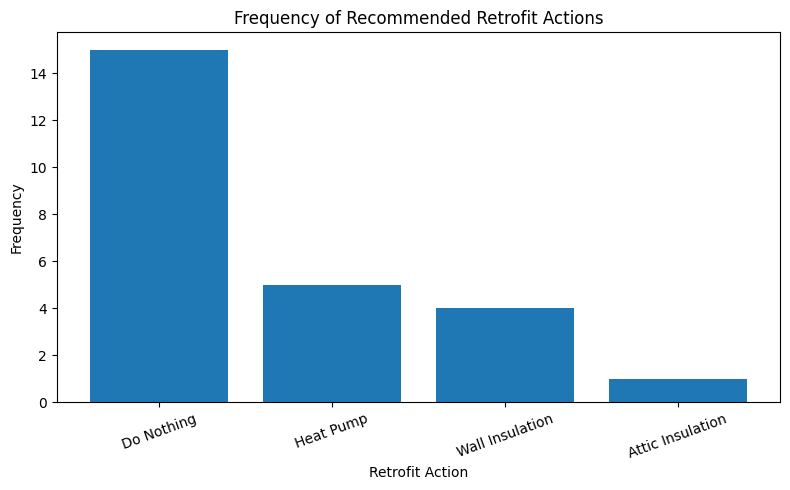

In [ ]:
# Retrofit Recommendation Frequency

plt.figure(figsize=(8,5))

plt.bar(

    action_frequency.index,

    action_frequency.values

)

plt.title("Frequency of Recommended Retrofit Actions")

plt.xlabel("Retrofit Action")

plt.ylabel("Frequency")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

In [ ]:
# Export Recommendations

summary_df.to_csv(

    "RETROFIT_DRL_Recommendations.csv",

    index=False

)

print("Recommendations exported successfully.")

Recommendations exported successfully.


In [ ]:
# Framework Demonstration

sample = retrofit_df.sample(3, random_state=42)

for i, idx in enumerate(sample.index):

    print("="*80)
    print(f"Sample Irish Dwelling {i+1}")
    print("="*80)

    display(sample.loc[[idx]])

    pathway = generate_retrofit_pathway(

        dqn_model,

        processed_df.loc[[idx]],

        budget=25000

    )

    display(pathway)

Sample Irish Dwelling 1


,DwellingTypeDescr,Year_of_Construction,GroundFloorArea(sq m),EnergyRating,BerRating,UValueWall,UValueRoof,UValueFloor,MainSpaceHeatingFuel,MainWaterHeatingFuel,ThermalEra,GlazingPercent,Volume
6252,Mid-terrace house,2004,69.26,C2,175.09,0.54,0.16,0.36,Heating Oil,Heating Oil,Post,0.158531,359.4594


,Year,Retrofit Action,Reward,Remaining Budget (€),Cumulative BER Improvement,Cumulative Energy Saving,Cumulative Carbon Reduction
0,1,Heat Pump,10.67,11000,21.0,8.92,10.50
1,2,Do Nothing,-1.00,11000,21.0,8.92,10.50
2,3,Do Nothing,-1.00,11000,21.0,8.92,10.50
3,4,Attic Insulation,0.29,8500,22.4,9.52,11.34
4,5,Do Nothing,-1.00,8500,22.4,9.52,11.34


Sample Irish Dwelling 2


,DwellingTypeDescr,Year_of_Construction,GroundFloorArea(sq m),EnergyRating,BerRating,UValueWall,UValueRoof,UValueFloor,MainSpaceHeatingFuel,MainWaterHeatingFuel,ThermalEra,GlazingPercent,Volume
4684,End of terrace house,2005,77.04,C1,173.76,0.3,0.2,0.37,Mains Gas,Mains Gas,Post,0.150037,399.0672


,Year,Retrofit Action,Reward,Remaining Budget (€),Cumulative BER Improvement,Cumulative Energy Saving,Cumulative Carbon Reduction
0,1,Heat Pump,10.67,11000,21.0,8.92,10.50
1,2,Do Nothing,-1.00,11000,21.0,8.92,10.50
2,3,Do Nothing,-1.00,11000,21.0,8.92,10.50
3,4,Do Nothing,-1.00,11000,21.0,8.92,10.50
4,5,Attic Insulation,0.29,8500,22.4,9.52,11.34


Sample Irish Dwelling 3


,DwellingTypeDescr,Year_of_Construction,GroundFloorArea(sq m),EnergyRating,BerRating,UValueWall,UValueRoof,UValueFloor,MainSpaceHeatingFuel,MainWaterHeatingFuel,ThermalEra,GlazingPercent,Volume
1731,Semi-detached house,1930,94.026,G,485.84,1.07,1.61,0.63,Heating Oil,Heating Oil,Pre,0.162418,234.12474


,Year,Retrofit Action,Reward,Remaining Budget (€),Cumulative BER Improvement,Cumulative Energy Saving,Cumulative Carbon Reduction
0,1,Wall Insulation,17.84,17000,28.0,11.90,16.8
1,2,Heat Pump,16.96,3000,58.0,24.65,31.8
2,3,Do Nothing,-1.00,3000,58.0,24.65,31.8
3,4,Do Nothing,-1.00,3000,58.0,24.65,31.8
4,5,Do Nothing,-1.00,3000,58.0,24.65,31.8


In [ ]:
# Final Performance Dashboard

dashboard = pd.DataFrame({

    "Metric":[

        "Average Reward",

        "BER Improvement",

        "Energy Saving",

        "Carbon Reduction",

        "Remaining Budget"

    ],

    "DQN":[

        round(dqn_results["Reward"],2),

        round(dqn_results["BER Improvement"],2),

        round(dqn_results["Energy Saving"],2),

        round(dqn_results["Carbon Reduction"],2),

        round(dqn_results["Remaining Budget"],2)

    ]

})

display(dashboard)

,Metric,DQN
0,Average Reward,15.03
1,BER Improvement,32.78
2,Energy Saving,13.93
3,Carbon Reduction,18.74
4,Remaining Budget,7745.00
